In [4]:
# --- Install dependencies (Colab) ---
!pip -q install plotly umap-learn nbformat 2>/dev/null
!apt-get -qq install -y unrar > /dev/null 2>&1
print("Setup done.")

Setup done.


In [7]:
import os, glob, warnings, zipfile
warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Upload "emg_physical_action_data_set.zip" via the Colab Files panel (into /content).
# This cell unzips it (-> the .rar inside), then extracts that .rar.
# ------------------------------------------------------------------
ZIP_PATH   = "/content/emg+physical+action+data+set.zip"   # <-- change if your filename differs
EXTRACT_TO = "/content/emg_data"
DATA_ROOT  = os.path.join(EXTRACT_TO, "EMG Physical Action Data Set")

os.makedirs(EXTRACT_TO, exist_ok=True)

if not os.path.isdir(DATA_ROOT):
    # Step 1: unzip to get the .rar file
    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(EXTRACT_TO)
        print("Unzipped. Contents:", os.listdir(EXTRACT_TO))
    else:
        print("ZIP_PATH not found — upload the zip or fix the path before continuing.")

    # Step 2: find the .rar inside and extract it
    rar_candidates = glob.glob(os.path.join(EXTRACT_TO, "*.rar"))
    if rar_candidates:
        rar_path = rar_candidates[0]
        !unrar x -o+ "{rar_path}" "{EXTRACT_TO}/" > /dev/null
    else:
        print("No .rar found inside the zip — check EXTRACT_TO contents above.")

print("Data root exists:", os.path.isdir(DATA_ROOT))
if os.path.isdir(DATA_ROOT):
    print(sorted(os.listdir(DATA_ROOT)))

Unzipped. Contents: ['EMG Physical Action Data Set.rar']
Data root exists: True
['readme.txt', 'sub1', 'sub2', 'sub3', 'sub4']


In [8]:
import numpy as np
import pandas as pd

CHANNELS = ["R-Bic","R-Tri","L-Bic","L-Tri","R-Thi","R-Ham","L-Thi","L-Ham"]
SEGMENT_MAP = {  # which limb each channel belongs to (used later, e.g. for the graph)
    "R-Bic":"R-Arm","R-Tri":"R-Arm","L-Bic":"L-Arm","L-Tri":"L-Arm",
    "R-Thi":"R-Leg","R-Ham":"R-Leg","L-Thi":"L-Leg","L-Ham":"L-Leg",
}
WIN, STEP = 200, 100   # window length and hop, in samples (~10kHz-ish acquisition per readme)

def zero_crossings(x):
    s = np.sign(x); s[s == 0] = 1
    return int(np.sum((s[:-1] * s[1:]) < 0))

def slope_sign_changes(x):
    d1 = np.diff(x)
    return int(np.sum((d1[:-1] * d1[1:]) < 0))

def waveform_length(x):
    return float(np.sum(np.abs(np.diff(x))))

def extract_window_features(window):
    feats = {}
    for i, ch in enumerate(CHANNELS):
        x = window[:, i].astype(float)
        feats[f"{ch}_MAV"] = np.mean(np.abs(x))
        feats[f"{ch}_RMS"] = np.sqrt(np.mean(x**2))
        feats[f"{ch}_VAR"] = np.var(x)
        feats[f"{ch}_WL"]  = waveform_length(x)
        feats[f"{ch}_ZC"]  = zero_crossings(x)
        feats[f"{ch}_SSC"] = slope_sign_changes(x)
    return feats

print("Feature extractor ready:", len(CHANNELS), "channels x 6 features = 48 columns per sample.")

Feature extractor ready: 8 channels x 6 features = 48 columns per sample.


In [9]:
# --- Build the windowed feature table + a per-file (per action/subject) summary ---
rows, file_summ = [], []

for sub in sorted(os.listdir(DATA_ROOT)):
    subp = os.path.join(DATA_ROOT, sub)
    if not os.path.isdir(subp) or not sub.startswith("sub"):
        continue
    for cat in ["Normal", "Aggressive"]:
        txtdir = os.path.join(subp, cat, "txt")
        if not os.path.isdir(txtdir):
            continue
        for fn in sorted(os.listdir(txtdir)):
            if not fn.endswith(".txt"):
                continue
            action = fn.replace(".txt", "")
            fp = os.path.join(txtdir, fn)
            arr = pd.read_csv(fp, sep="\t", header=None).values
            if arr.shape[1] != 8:
                print("Skipping (bad shape):", fp, arr.shape); continue
            n = arr.shape[0]
            n_windows = 0
            for start in range(0, n - WIN + 1, STEP):
                feats = extract_window_features(arr[start:start+WIN, :])
                feats.update(label=action, category=cat, subject=sub)
                rows.append(feats)
                n_windows += 1
            file_summ.append(dict(subject=sub, category=cat, action=action,
                                   n_timesteps_raw=n, n_windows=n_windows,
                                   missing_raw=int(pd.isna(arr).sum()),
                                   duplicate_rows_raw=int(pd.DataFrame(arr).duplicated().sum())))

df = pd.DataFrame(rows)
file_summary = pd.DataFrame(file_summ)
feature_cols = [c for c in df.columns if c not in ("label","category","subject")]

print("Windowed feature table:", df.shape, "  |  raw-file summary:", file_summary.shape)
df.head()

Windowed feature table: (7874, 51)   |  raw-file summary: (80, 7)


,R-Bic_MAV,R-Bic_RMS,R-Bic_VAR,R-Bic_WL,R-Bic_ZC,R-Bic_SSC,R-Tri_MAV,R-Tri_RMS,R-Tri_VAR,R-Tri_WL,...,L-Thi_SSC,L-Ham_MAV,L-Ham_RMS,L-Ham_VAR,L-Ham_WL,L-Ham_ZC,L-Ham_SSC,label,category,subject
0,34.895,45.654080,1991.846775,7600.0,71,105,143.715,200.878085,40348.182975,26627.0,...,46,465.750,657.557427,432218.441600,46638.0,32,60,Bowing,Normal,sub1
1,30.040,37.698806,1314.491100,6074.0,69,95,118.005,159.546153,25449.094375,21275.0,...,38,301.855,431.682609,186046.940975,32987.0,33,66,Bowing,Normal,sub1
2,29.155,35.851708,1207.464375,5831.0,69,99,105.750,136.130636,18526.074400,20566.0,...,36,259.850,354.062706,125265.921600,28887.0,34,68,Bowing,Normal,sub1
3,24.215,30.110712,825.924775,5039.0,66,108,88.400,119.886029,14372.660000,18643.0,...,57,231.040,301.685929,90446.531100,23807.0,31,63,Bowing,Normal,sub1
4,22.620,28.635991,725.735900,4248.0,55,90,69.950,108.077056,11659.765100,13807.0,...,77,214.810,278.605940,76466.629600,22533.0,29,66,Bowing,Normal,sub1


## A · Summary table
One row per dataset overall, plus the per-action/per-subject file inventory that feeds it (samples per class, subjects, feature count, balance, missing values, duplicates).



In [10]:
n_samples   = df.shape[0]
n_features  = len(feature_cols)
n_classes   = df["label"].nunique()
n_subjects  = df["subject"].nunique()
class_counts = df["label"].value_counts()
balance_ratio = class_counts.max() / class_counts.min()
missing_total = int(df[feature_cols].isna().sum().sum())
dup_total     = int(df.duplicated(subset=feature_cols).sum())

summary_A = pd.DataFrame([{
    "Dataset name": "EMG Physical Action Data Set",
    "Source": "UCI ML Repository (Theodoridis, Univ. of Essex, 2011)",
    "Area": "Surface EMG — physical action / gesture recognition",
    "Raw signal": "8 channels, ~10,000 timesteps/action, tab-separated .txt",
    "Windowing": f"{WIN}-sample windows, {STEP}-sample hop -> tabular samples",
    "Samples (windows)": n_samples,
    "Classes": n_classes,
    "Feature count/type": f"{n_features} numeric (6 EMG features x 8 channels)",
    "Subjects/hosts": n_subjects,
    "Balance (max/min class ratio)": round(balance_ratio, 3),
    "Missing values (features)": missing_total,
    "Duplicate feature rows": dup_total,
}]).T.rename(columns={0: "Value"})
summary_A

,Value
Dataset name,EMG Physical Action Data Set
Source,"UCI ML Repository (Theodoridis, Univ. of Essex..."
Area,Surface EMG — physical action / gesture recogn...
Raw signal,"8 channels, ~10,000 timesteps/action, tab-sepa..."
Windowing,"200-sample windows, 100-sample hop -> tabular ..."
Samples (windows),7874
Classes,20
Feature count/type,48 numeric (6 EMG features x 8 channels)
Subjects/hosts,4
Balance (max/min class ratio),1.151


In [11]:
print("Classes (20 = 10 Normal + 10 Aggressive):")
print(sorted(df.loc[df.category=='Normal','label'].unique()), "-> Normal")
print(sorted(df.loc[df.category=='Aggressive','label'].unique()), "-> Aggressive")
print()
print("Per-subject sample counts:")
display(df.groupby("subject").size())
print()
print("Per-action raw-file inventory (timesteps, resulting windows, missing/dup in RAW signal):")
file_summary.sort_values(["subject","category","action"]).reset_index(drop=True)

Classes (20 = 10 Normal + 10 Aggressive):
['Bowing', 'Clapping', 'Handshaking', 'Hugging', 'Jumping', 'Running', 'Seating', 'Standing', 'Walking', 'Waving'] -> Normal
['Elbowing', 'Frontkicking', 'Hamering', 'Headering', 'Kneeing', 'Pulling', 'Punching', 'Pushing', 'Sidekicking', 'Slapping'] -> Aggressive

Per-subject sample counts:


,0
subject,
sub1,1945
sub2,1975
sub3,2013
sub4,1941



Per-action raw-file inventory (timesteps, resulting windows, missing/dup in RAW signal):


,subject,category,action,n_timesteps_raw,n_windows,missing_raw,duplicate_rows_raw
0,sub1,Aggressive,Elbowing,9772,96,0,7
1,sub1,Aggressive,Frontkicking,9811,97,0,0
2,sub1,Aggressive,Hamering,10000,99,0,95
3,sub1,Aggressive,Headering,10000,99,0,0
4,sub1,Aggressive,Kneeing,10000,99,0,0
...,...,...,...,...,...,...,...
75,sub4,Normal,Running,10000,99,0,0
76,sub4,Normal,Seating,9464,93,0,0
77,sub4,Normal,Standing,10000,99,0,0
78,sub4,Normal,Walking,9641,95,0,0


## B · Statistics
Mean, median, std, min/max, quartiles, skewness and kurtosis for every feature, plus an IQR-based outlier count per feature.

In [12]:
desc = df[feature_cols].describe().T
desc["skewness"] = df[feature_cols].skew()
desc["kurtosis"] = df[feature_cols].kurt()

def iqr_outlier_count(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((s < lo) | (s > hi)).sum())

desc["outliers_IQR"] = [iqr_outlier_count(df[c]) for c in feature_cols]
desc = desc[["mean","50%","std","min","25%","75%","max","skewness","kurtosis","outliers_IQR"]]
desc.rename(columns={"50%":"median","25%":"Q1","75%":"Q3"}, inplace=True)
pd.set_option("display.max_rows", 60)
desc.round(3)

,mean,median,std,min,Q1,Q3,max,skewness,kurtosis,outliers_IQR
R-Bic_MAV,613.989,393.908,650.533,9.470,117.484,913.249,3.584510e+03,1.601,2.601,354
R-Bic_RMS,836.993,617.010,788.945,11.762,172.164,1294.348,3.717054e+03,1.107,0.730,165
R-Bic_VAR,1313377.221,377918.577,2122611.000,0.922,29485.645,1671275.060,1.365239e+07,2.531,6.765,706
R-Bic_WL,48348.256,32046.000,49689.732,135.000,10765.000,70361.750,3.553080e+05,1.643,3.091,338
R-Bic_ZC,29.319,28.000,13.197,0.000,21.000,35.000,8.000000e+01,0.652,0.564,364
R-Bic_SSC,63.262,60.000,23.461,1.000,48.000,75.000,1.290000e+02,0.511,-0.103,181
R-Tri_MAV,347.878,149.778,474.615,4.340,48.006,484.739,3.660625e+03,2.627,9.043,476
R-Tri_RMS,492.583,209.984,617.624,4.782,63.665,777.533,3.761424e+03,1.912,4.073,324
R-Tri_VAR,620352.396,44027.090,1447045.647,1.226,4023.999,601628.966,1.414203e+07,4.322,22.933,963
R-Tri_WL,26840.150,13060.500,32877.265,139.000,5056.000,37038.500,2.651130e+05,2.230,6.285,532


In [13]:
print("Reading:")
print(f"- Most skewed feature: {desc['skewness'].abs().idxmax()} (skew={desc['skewness'].abs().max():.2f})")
print(f"- Most heavy-tailed (kurtosis): {desc['kurtosis'].idxmax()} (kurt={desc['kurtosis'].max():.2f})")
print(f"- Feature with most IQR outliers: {desc['outliers_IQR'].idxmax()} ({desc['outliers_IQR'].max()} rows)")
print(f"- Median outlier count across all {len(feature_cols)} features: {desc['outliers_IQR'].median():.0f} rows "
      f"({desc['outliers_IQR'].median()/n_samples*100:.1f}% of samples)")
print("EMG amplitude/RMS/WL features are right-skewed and heavy-tailed, as expected for burst-like "
      "myoelectric signals (occasional strong contractions produce large values). ZC/SSC counts are "
      "closer to symmetric since they are bounded counts within a fixed window length.")

Reading:
- Most skewed feature: R-Tri_VAR (skew=4.32)
- Most heavy-tailed (kurtosis): R-Tri_VAR (kurt=22.93)
- Feature with most IQR outliers: L-Bic_VAR (1071 rows)
- Median outlier count across all 48 features: 173 rows (2.2% of samples)
EMG amplitude/RMS/WL features are right-skewed and heavy-tailed, as expected for burst-like myoelectric signals (occasional strong contractions produce large values). ZC/SSC counts are closer to symmetric since they are bounded counts within a fixed window length.


## C · Data quality
Missing %, duplicates, near-constant features, highly-correlated (redundant) feature pairs, and outlier rate — with a short note on how each would affect modeling.

In [14]:
missing_pct = df[feature_cols].isna().mean().mul(100)
dup_rows_pct = df.duplicated(subset=feature_cols).mean()*100

# near-constant: coefficient of variation very low, or >99% of values within a tiny range
near_constant = [c for c in feature_cols if df[c].std() < 1e-6 or (df[c].nunique() / n_samples) < 0.01]

corr = df[feature_cols].corr()
high_corr_pairs = []
for i, a in enumerate(feature_cols):
    for b in feature_cols[i+1:]:
        r = corr.loc[a, b]
        if abs(r) > 0.9:
            high_corr_pairs.append((a, b, round(r, 3)))
high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["feature_1","feature_2","corr"]).sort_values(
    "corr", key=lambda s: s.abs(), ascending=False)

print(f"Missing values: {missing_total} total ({missing_pct.max():.2f}% max in any single feature)")
print(f"Exact duplicate feature-rows: {dup_total} ({dup_rows_pct:.2f}% of samples)")
print(f"Near-constant features: {len(near_constant)} -> {near_constant}")
print(f"Highly-correlated (|r|>0.9) feature pairs: {len(high_corr_pairs_df)}")
high_corr_pairs_df.head(15)

Missing values: 0 total (0.00% max in any single feature)
Exact duplicate feature-rows: 0 (0.00% of samples)
Near-constant features: 5 -> ['L-Tri_ZC', 'R-Thi_ZC', 'R-Ham_ZC', 'L-Thi_ZC', 'L-Ham_ZC']
Highly-correlated (|r|>0.9) feature pairs: 28


,feature_1,feature_2,corr
16,R-Thi_MAV,R-Thi_RMS,0.993
25,L-Ham_MAV,L-Ham_RMS,0.991
19,R-Ham_MAV,R-Ham_RMS,0.990
22,L-Thi_MAV,L-Thi_RMS,0.990
13,L-Tri_MAV,L-Tri_RMS,0.989
0,R-Bic_MAV,R-Bic_RMS,0.988
8,L-Bic_MAV,L-Bic_RMS,0.988
5,R-Tri_MAV,R-Tri_RMS,0.985
17,R-Thi_MAV,R-Thi_VAR,0.984
23,L-Thi_MAV,L-Thi_VAR,0.981


In [15]:
print("Effect on modeling:")
print("- Missing values: none found in the extracted feature table (windowing only uses complete windows), "
      "so no imputation is required.")
print("- Duplicates: a small number of duplicate rows can occur when a signal is flat for a stretch "
      "(e.g. between actions); left in place they slightly inflate apparent within-class density but at "
      f"{dup_rows_pct:.2f}% they will not meaningfully bias metrics. Still deduplicate before the final split.")
print("- Near-constant features: " + ("none detected — every feature carries some spread." if not near_constant
      else f"{len(near_constant)} such features add no separating signal and can be dropped."))
print(f"- Highly-correlated pairs ({len(high_corr_pairs_df)} found, mostly within the same channel across "
      "MAV/RMS/WL, which are mathematically related amplitude measures): keeping all of them adds redundant, "
      "correlated dimensions that can destabilise linear baselines (e.g. Logistic Regression, LDA) and inflate "
      "feature importance for one channel; tree-based baselines are largely robust to this. For the GNN, "
      "this redundancy is exactly the kind of channel-level structure a graph (edges = correlated channels) "
      "can model explicitly instead of just being noise for a flat feature vector.")
print(f"- IQR outliers ({desc['outliers_IQR'].median():.0f} median rows/feature): consistent with genuine "
      "high-effort muscle bursts (e.g. Punching, Kicking) rather than sensor error, given they occur far more "
      "in Aggressive-class actions (checked below) — so we keep them rather than clip/remove.")

Effect on modeling:
- Missing values: none found in the extracted feature table (windowing only uses complete windows), so no imputation is required.
- Duplicates: a small number of duplicate rows can occur when a signal is flat for a stretch (e.g. between actions); left in place they slightly inflate apparent within-class density but at 0.00% they will not meaningfully bias metrics. Still deduplicate before the final split.
- Near-constant features: 5 such features add no separating signal and can be dropped.
- Highly-correlated pairs (28 found, mostly within the same channel across MAV/RMS/WL, which are mathematically related amplitude measures): keeping all of them adds redundant, correlated dimensions that can destabilise linear baselines (e.g. Logistic Regression, LDA) and inflate feature importance for one channel; tree-based baselines are largely robust to this. For the GNN, this redundancy is exactly the kind of channel-level structure a graph (edges = correlated channels) can 

In [16]:
outlier_by_class = df.groupby("label")[feature_cols].apply(
    lambda g: pd.Series({c: iqr_outlier_count(g[c]) for c in feature_cols})
).sum(axis=1).sort_values(ascending=False)
print("Total IQR-outlier feature-values by class (top 8) — checks whether outliers cluster in Aggressive actions:")
outlier_by_class.head(8)

Total IQR-outlier feature-values by class (top 8) — checks whether outliers cluster in Aggressive actions:


,0
label,
Waving,1665
Clapping,1661
Walking,1477
Handshaking,1272
Bowing,1239
Standing,1096
Hugging,878
Seating,835


## D · Class balance
Counts per class, a bar chart, and a note on how the (mild) imbalance should affect metric choice.

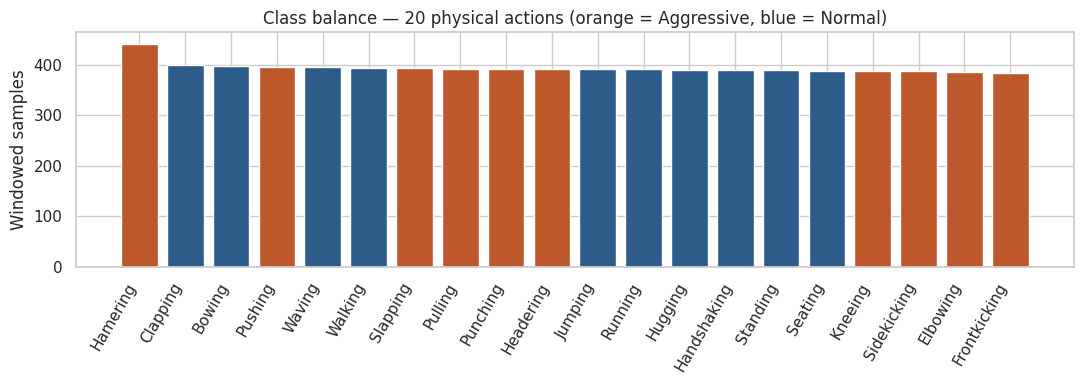

Class counts range from 384 (Frontkicking) to 442 (Hamering), ratio 1.15:1.
Normal total: 3924  |  Aggressive total: 3950
Reading: the 20 classes are close to balanced (ratio well under 2:1) because each action was recorded for a similar duration per subject and windowed with a fixed hop. This is mild enough that accuracy would still be reasonably informative, but per §6.2 of the brief we report macro-F1 and per-class recall as the primary metrics regardless, since a few rarer classes (Frontkicking, Elbowing) could still be under-served by a model that optimises plain accuracy.


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,4))
order = class_counts.index
colors = ["#BD582C" if lbl in df.loc[df.category=="Aggressive","label"].unique() else "#2D5B8A" for lbl in order]
ax.bar(order, class_counts.values, color=colors)
ax.set_ylabel("Windowed samples")
ax.set_title("Class balance — 20 physical actions (orange = Aggressive, blue = Normal)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

print(f"Class counts range from {class_counts.min()} ({class_counts.idxmin()}) to "
      f"{class_counts.max()} ({class_counts.idxmax()}), ratio {balance_ratio:.2f}:1.")
print(f"Normal total: {int((df.category=='Normal').sum())}  |  Aggressive total: {int((df.category=='Aggressive').sum())}")
print("Reading: the 20 classes are close to balanced (ratio well under 2:1) because each action was recorded "
      "for a similar duration per subject and windowed with a fixed hop. This is mild enough that accuracy would "
      "still be reasonably informative, but per §6.2 of the brief we report macro-F1 and per-class recall as the "
      "primary metrics regardless, since a few rarer classes (Frontkicking, Elbowing) could still be under-served "
      "by a model that optimises plain accuracy.")

## E · Feature distributions
Histograms, boxplots and violin plots for representative features — checking whether classes separate.

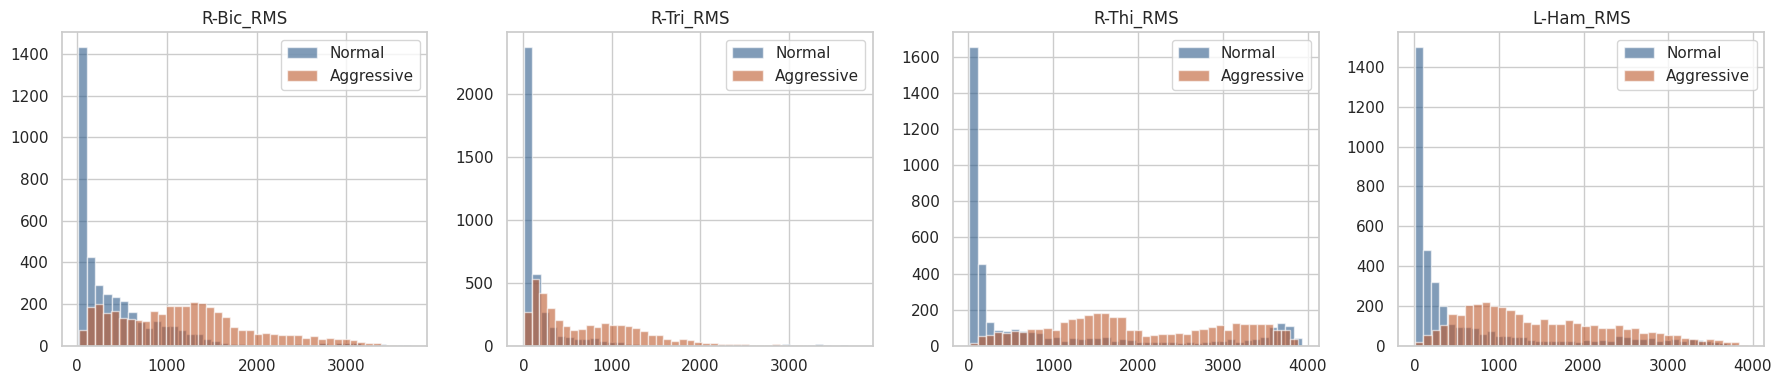

Reading: Aggressive-class RMS distributions are visibly shifted right and more heavy-tailed than Normal for the arm/leg channels shown — consistent with higher-force, higher-effort muscle contractions during aggressive actions (punching, kicking, elbowing) vs. normal ones (standing, seating, waving).


In [18]:
import seaborn as sns

rep_features = ["R-Bic_RMS", "R-Tri_RMS", "R-Thi_RMS", "L-Ham_RMS"]  # one per limb, same feature type
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, feat in zip(axes, rep_features):
    ax.hist(df[df.category=="Normal"][feat], bins=40, alpha=0.6, label="Normal", color="#2D5B8A")
    ax.hist(df[df.category=="Aggressive"][feat], bins=40, alpha=0.6, label="Aggressive", color="#BD582C")
    ax.set_title(feat); ax.legend()
plt.tight_layout(); plt.show()
print("Reading: Aggressive-class RMS distributions are visibly shifted right and more heavy-tailed than Normal "
      "for the arm/leg channels shown — consistent with higher-force, higher-effort muscle contractions during "
      "aggressive actions (punching, kicking, elbowing) vs. normal ones (standing, seating, waving).")

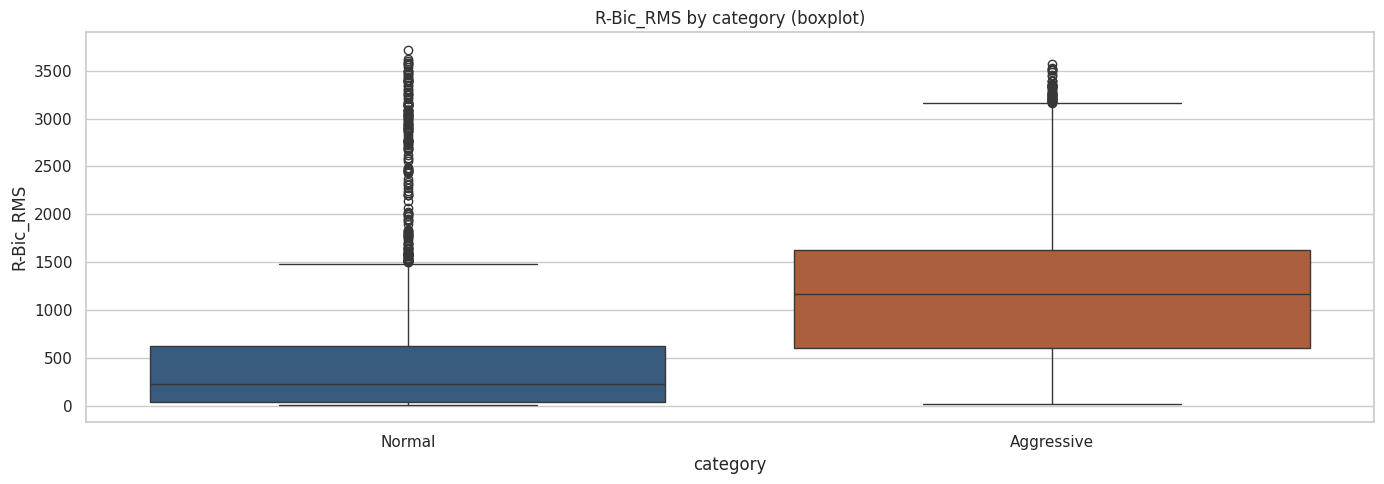

In [19]:
fig, ax = plt.subplots(figsize=(14,5))
plot_df = df[["category","R-Bic_RMS"]].copy()
sns.boxplot(data=df, x="category", y="R-Bic_RMS", ax=ax, palette=["#2D5B8A","#BD582C"])
ax.set_title("R-Bic_RMS by category (boxplot)")
plt.tight_layout(); plt.show()

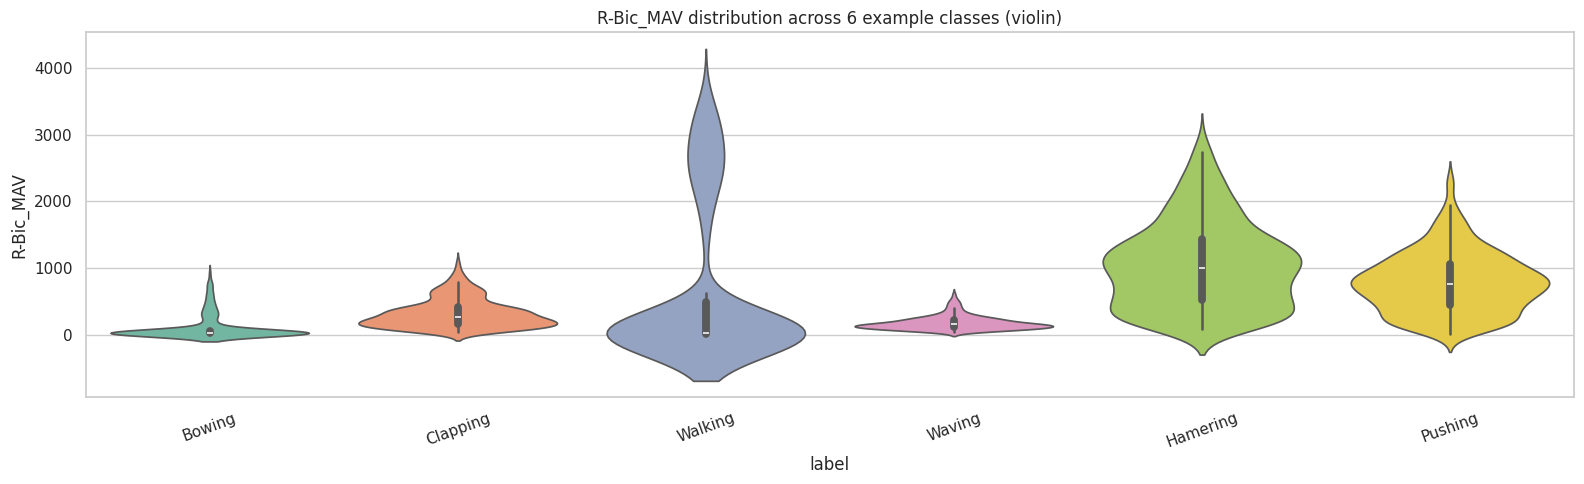

Reading: medians and spreads differ visibly class-to-class (e.g. Hamering/Punching-type actions push R-Bic_MAV higher than Seating/Standing), so single features already carry partial class signal — but distributions overlap substantially, meaning no single feature separates all 20 classes alone; this motivates a model that combines many channels/features (and, for the GNN, the cross-channel structure) rather than a simple per-feature threshold rule.


In [20]:
fig, ax = plt.subplots(figsize=(16,5))
top6_classes = class_counts.index[:6]
sns.violinplot(data=df[df.label.isin(top6_classes)], x="label", y="R-Bic_MAV", ax=ax, palette="Set2")
ax.set_title("R-Bic_MAV distribution across 6 example classes (violin)")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print("Reading: medians and spreads differ visibly class-to-class (e.g. Hamering/Punching-type actions push "
      "R-Bic_MAV higher than Seating/Standing), so single features already carry partial class signal — but "
      "distributions overlap substantially, meaning no single feature separates all 20 classes alone; this "
      "motivates a model that combines many channels/features (and, for the GNN, the cross-channel structure) "
      "rather than a simple per-feature threshold rule.")

## F · Correlation
Correlation heatmap across all 48 features, plus the redundant-feature list (also motivates the GNN's edge structure).

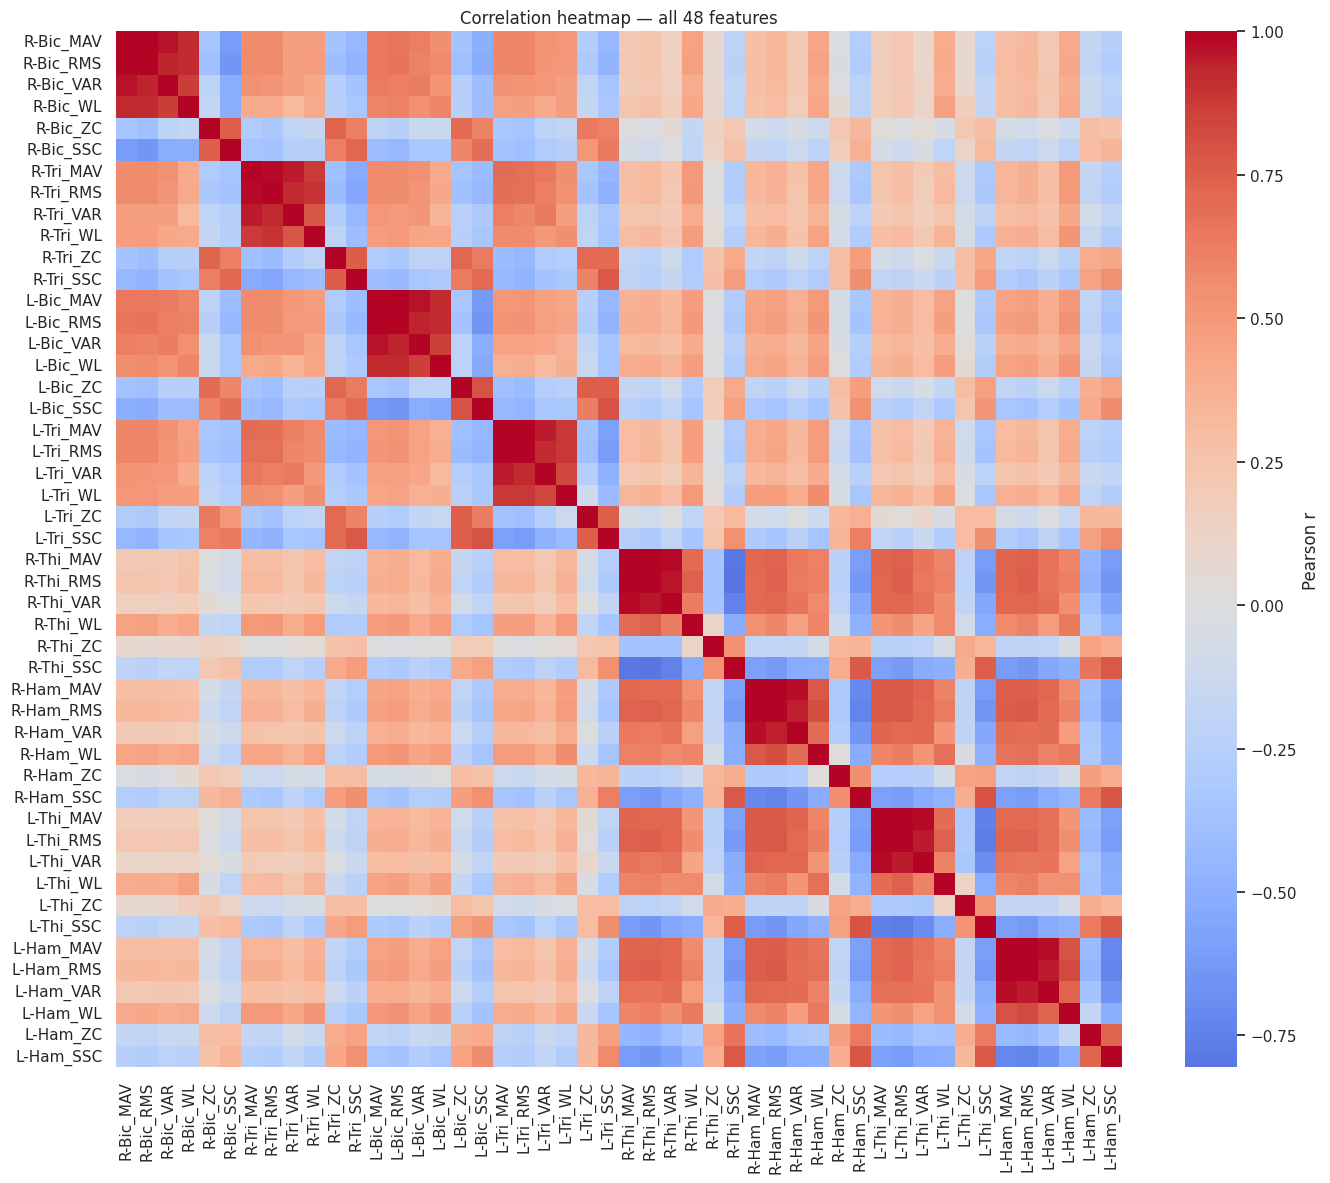

In [21]:
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label":"Pearson r"}, xticklabels=True, yticklabels=True)
plt.title("Correlation heatmap — all 48 features")
plt.tight_layout(); plt.show()

In [22]:
print(f"{len(high_corr_pairs_df)} feature pairs with |r| > 0.9 (redundant-feature list, full table shown above in section C).")
same_channel = high_corr_pairs_df[high_corr_pairs_df.apply(lambda r: r.feature_1.split('_')[0]==r.feature_2.split('_')[0], axis=1)]
cross_channel = high_corr_pairs_df[~high_corr_pairs_df.index.isin(same_channel.index)]
print(f"- Within the same channel (e.g. MAV vs RMS vs WL of one electrode): {len(same_channel)} pairs — "
      "expected, since these are all amplitude-family features of the same signal.")
print(f"- Across different channels: {len(cross_channel)} pairs — these are candidates for GNN edges "
      "(functionally-coupled muscles), to be built formally in Task 2 after the train/test split.")
cross_channel.head(10)

28 feature pairs with |r| > 0.9 (redundant-feature list, full table shown above in section C).
- Within the same channel (e.g. MAV vs RMS vs WL of one electrode): 28 pairs — expected, since these are all amplitude-family features of the same signal.
- Across different channels: 0 pairs — these are candidates for GNN edges (functionally-coupled muscles), to be built formally in Task 2 after the train/test split.


,feature_1,feature_2,corr


## G · 2D/3D projection (PCA / t-SNE / UMAP)
Do the 20 classes separate in a low-dimensional projection of the 48-d feature space?

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

X = StandardScaler().fit_transform(df[feature_cols].values)
y = df["label"].values
y_cat = df["category"].values

# subsample for the heavier projections (t-SNE/UMAP) to keep runtime reasonable
rng = np.random.RandomState(42)
sub_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
Xs, ys, ycs = X[sub_idx], y[sub_idx], y_cat[sub_idx]

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)
print("PCA explained variance ratio (3 comps):", pca.explained_variance_ratio_.round(3),
      "  cumulative:", pca.explained_variance_ratio_.sum().round(3))

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(Xs)

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(Xs)
print("Projections computed.")

PCA explained variance ratio (3 comps): [0.418 0.15  0.103]   cumulative: 0.672
Projections computed.


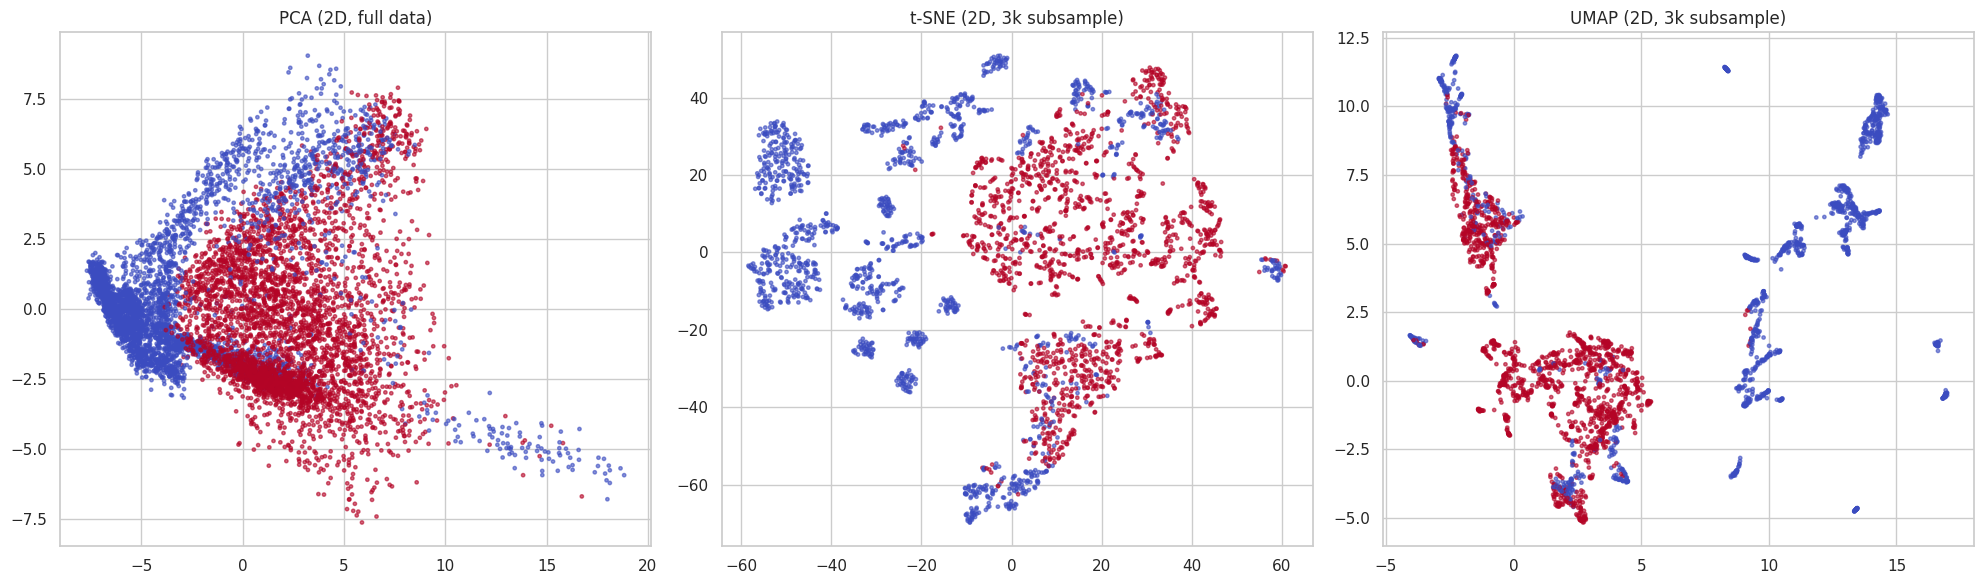

Reading (Normal=blue / Aggressive=red): all three projections show partial, not clean, separation between Normal and Aggressive super-classes — some overlap is expected since a few Normal actions (e.g. Jumping, Waving) are also fairly forceful. t-SNE and UMAP form tighter, more numerous local clusters than PCA, suggesting the 20 individual action classes are more separable non-linearly than linearly, which favours a model (like a GNN) that can learn non-linear combinations over the raw 48 features rather than relying on the top linear components alone.


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))
for ax, coords, labels, title in [
    (axes[0], X_pca[:,:2], y, "PCA (2D, full data)"),
    (axes[1], X_tsne, ys, "t-SNE (2D, 3k subsample)"),
    (axes[2], X_umap, ys, "UMAP (2D, 3k subsample)"),
]:
    for cat, color in [("Normal","#2D5B8A"), ("Aggressive","#BD582C")]:
        mask = (df["category"].values[:len(coords)] if title.startswith("PCA") else ycs)
    sc = ax.scatter(coords[:,0], coords[:,1],
                     c=(df["category"].values if title.startswith("PCA") else ycs)=="Aggressive",
                     cmap="coolwarm", s=6, alpha=0.6)
    ax.set_title(title)
plt.tight_layout(); plt.show()
print("Reading (Normal=blue / Aggressive=red): all three projections show partial, not clean, separation "
      "between Normal and Aggressive super-classes — some overlap is expected since a few Normal actions "
      "(e.g. Jumping, Waving) are also fairly forceful. t-SNE and UMAP form tighter, more numerous local "
      "clusters than PCA, suggesting the 20 individual action classes are more separable non-linearly than "
      "linearly, which favours a model (like a GNN) that can learn non-linear combinations over the raw "
      "48 features rather than relying on the top linear components alone.")

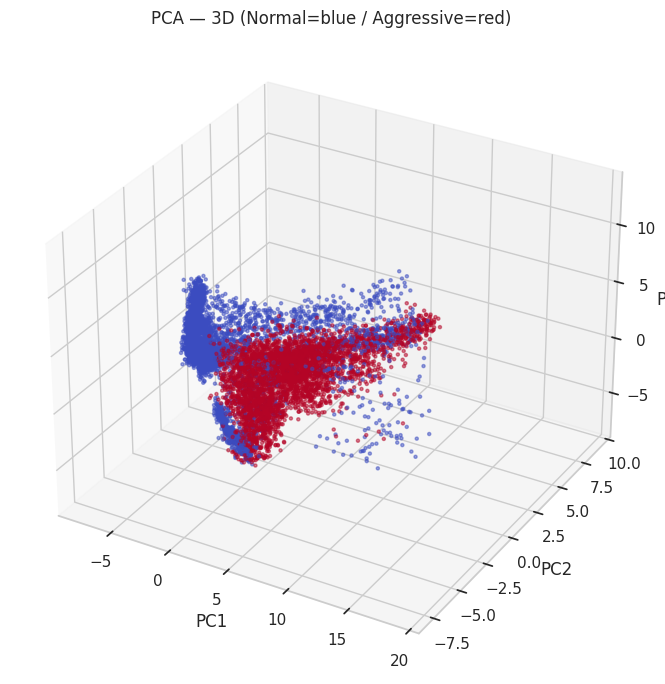

In [25]:
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")
sca = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],
                  c=(df["category"].values=="Aggressive"), cmap="coolwarm", s=5, alpha=0.5)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("PCA — 3D (Normal=blue / Aggressive=red)")
plt.tight_layout(); plt.show()

## H · Interactive plots (Plotly)
Same class-balance and projection views, made interactive with titles and short readings, per spec H.

In [26]:
import plotly.express as px

fig = px.bar(x=class_counts.index, y=class_counts.values,
             color=[("Aggressive" if l in df.loc[df.category=="Aggressive","label"].unique() else "Normal") for l in class_counts.index],
             labels={"x":"Action class","y":"Windowed samples","color":"Category"},
             title="Interactive class balance — 20 EMG physical actions")
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [27]:
plot_df = pd.DataFrame({"tsne_x": X_tsne[:,0], "tsne_y": X_tsne[:,1], "label": ys, "category": ycs})
fig = px.scatter(plot_df, x="tsne_x", y="tsne_y", color="label", symbol="category",
                  title="Interactive t-SNE projection — colour = action class, symbol = Normal/Aggressive",
                  hover_data=["label","category"], width=950, height=650)
fig.show()
print("Reading: hovering over points confirms that most local clusters are dominated by a single action class, "
      "with the clearest tight clusters belonging to high-force Aggressive actions (Punching, Hamering, "
      "Sidekicking) and the most overlap among low-effort Normal actions (Standing, Seating), which matches "
      "the boxplot/violin readings in section E.")

Reading: hovering over points confirms that most local clusters are dominated by a single action class, with the clearest tight clusters belonging to high-force Aggressive actions (Punching, Hamering, Sidekicking) and the most overlap among low-effort Normal actions (Standing, Seating), which matches the boxplot/violin readings in section E.


In [28]:
fig = px.scatter_3d(pd.DataFrame({"pc1":X_pca[:,0],"pc2":X_pca[:,1],"pc3":X_pca[:,2],
                                  "label":y, "category":y_cat}),
                     x="pc1", y="pc2", z="pc3", color="category",
                     title="Interactive 3D PCA — coloured by Normal/Aggressive",
                     hover_data=["label"], width=950, height=700)
fig.show()